# 🌍 Air Quality Index (AQI) — Exploratory Data Analysis

**Dataset:** Air Quality Data in India (CPCB via Kaggle)  
**Author:** Omkar Avasarkar  
**Goal:** Understand pollutant distributions, correlations, city-wise trends, and seasonal patterns before model training.

## 1. Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load Dataset

In [18]:
df = pd.read_csv('aqi_data.csv')

print(f'Shape      : {df.shape}')
print(f'Columns    : {list(df.columns)}')
print(f'Null values: {df.isnull().sum().sum()}')
df.head()

Shape      : (16010, 7)
Columns    : ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'AQI']
Null values: 0


,PM2.5,PM10,NO2,SO2,CO,O3,AQI
0,37.55,122.41,85.12,163.01,15.08,48.23,281.0
1,33.97,116.32,79.71,91.26,14.67,51.86,330.0
2,35.48,130.07,77.61,98.35,18.02,38.99,356.0
3,34.11,138.31,75.23,88.66,13.27,42.22,359.0
4,33.69,111.73,68.90,80.90,34.56,36.95,547.0


In [19]:
df.describe().round(2)

,PM2.5,PM10,NO2,SO2,CO,O3,AQI
count,16010.00,16010.00,16010.00,16010.00,16010.00,16010.00,16010.00
mean,57.34,117.70,29.11,12.79,1.43,35.13,141.36
std,52.10,88.48,22.83,13.50,3.55,21.53,104.33
min,0.16,0.18,0.01,0.01,0.00,0.01,14.00
25%,25.04,56.62,12.45,6.12,0.56,19.68,74.00
50%,42.91,95.62,24.10,9.71,0.84,31.96,107.00
75%,69.80,148.70,39.37,14.68,1.25,46.20,167.00
max,868.66,847.41,277.31,186.08,92.96,257.73,1389.00


## 3. AQI Distribution

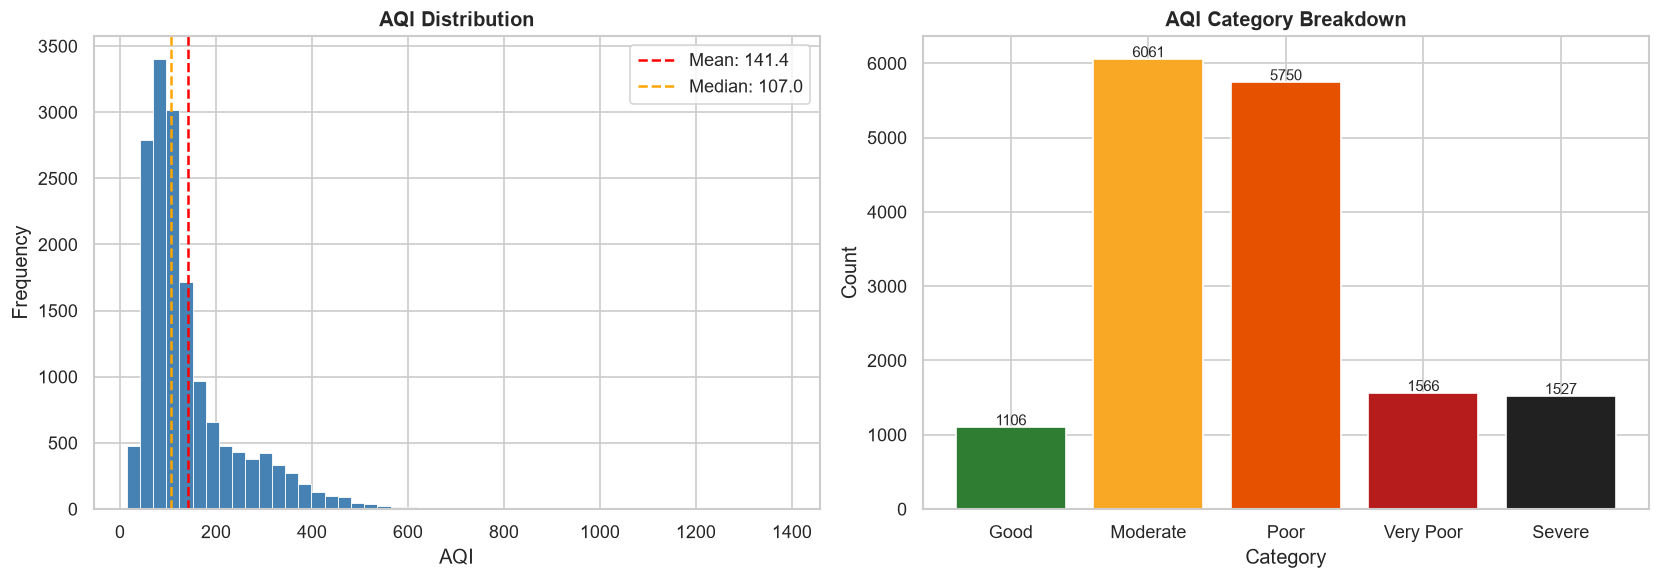

AQI_Category
Good         1106
Moderate     6061
Poor         5750
Very Poor    1566
Severe       1527


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['AQI'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['AQI'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {df['AQI'].mean():.1f}")
axes[0].axvline(df['AQI'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median: {df['AQI'].median():.1f}")
axes[0].set_title('AQI Distribution', fontweight='bold')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# AQI category breakdown
def aqi_category(aqi):
    if aqi <= 50:   return 'Good'
    elif aqi <= 100: return 'Moderate'
    elif aqi <= 200: return 'Poor'
    elif aqi <= 300: return 'Very Poor'
    else:            return 'Severe'

df['AQI_Category'] = df['AQI'].apply(aqi_category)
cat_counts = df['AQI_Category'].value_counts()
colors = ['#2e7d32','#f9a825','#e65100','#b71c1c','#212121']
order = ['Good','Moderate','Poor','Very Poor','Severe']
cat_counts = cat_counts.reindex([o for o in order if o in cat_counts.index])

axes[1].bar(cat_counts.index, cat_counts.values,
            color=colors[:len(cat_counts)], edgecolor='white')
axes[1].set_title('AQI Category Breakdown', fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
for i, v in enumerate(cat_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('screenshots/01_aqi_distribution.png', bbox_inches='tight')
plt.show()
print(cat_counts.to_string())

## 4. Pollutant Distributions

In [ ]:
FEATURES = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2,
                    label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel('Concentration')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Pollutant Concentration Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('screenshots/02_pollutant_distributions.png', bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap

In [ ]:
corr_cols = FEATURES + ['AQI']
corr = df[corr_cols].corr().round(2)

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    annot_kws={'size': 10}
)
plt.title('Pollutant Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('screenshots/03_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('\nCorrelation with AQI (sorted):')
print(corr['AQI'].drop('AQI').sort_values(ascending=False).to_string())

## 6. Pollutant vs AQI Scatter Plots

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    axes[i].scatter(df[col], df['AQI'], alpha=0.3, s=8, color='steelblue')
    # Trend line
    z = np.polyfit(df[col], df['AQI'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend')
    axes[i].set_title(f'{col} vs AQI', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('AQI')
    axes[i].legend(fontsize=8)

plt.suptitle('Pollutant vs AQI Scatter Plots', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('screenshots/04_scatter_plots.png', bbox_inches='tight')
plt.show()

## 7. Outlier Detection — Boxplots

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pollutants boxplot (normalised for comparison)
df_norm = df[FEATURES].copy()
for col in FEATURES:
    df_norm[col] = (df_norm[col] - df_norm[col].min()) / (df_norm[col].max() - df_norm[col].min())

axes[0].boxplot([df_norm[col].dropna() for col in FEATURES],
tick_labels=FEATURES, patch_artist=True,                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('Pollutant Distributions (Normalised)', fontweight='bold')
axes[0].set_ylabel('Normalised Value (0–1)')
axes[0].tick_params(axis='x', rotation=15)

# AQI boxplot
axes[1].boxplot(df['AQI'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='salmon', alpha=0.7))
axes[1].set_title('AQI Outlier Distribution', fontweight='bold')
axes[1].set_ylabel('AQI')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['AQI'])

plt.tight_layout()
plt.savefig('screenshots/05_boxplots.png', bbox_inches='tight')
plt.show()

# Outlier count
print('Outliers per pollutant (beyond 1.5x IQR):')
for col in FEATURES + ['AQI']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'  {col:<8}: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

## 8. Feature Importance (from trained model)

In [ ]:
import pickle

saved = pickle.load(open('model.pkl', 'rb'))
model    = saved['model']
features = saved['features']

importances = model.feature_importances_
fi_df = pd.DataFrame({'Pollutant': features, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

colors = ['#1565c0' if p != fi_df['Pollutant'].iloc[-1] else '#e65100'
          for p in fi_df['Pollutant']]

plt.figure(figsize=(8, 4))
bars = plt.barh(fi_df['Pollutant'], fi_df['Importance'], color=colors, height=0.55)
for bar, val in zip(bars, fi_df['Importance']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance — Gradient Boosting Model', fontweight='bold')
plt.xlim(0, fi_df['Importance'].max() * 1.2)
plt.tight_layout()
plt.savefig('screenshots/06_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nFeature Importance:')
print(fi_df.sort_values('Importance', ascending=False).to_string(index=False))

## 9. Key Insights Summary

In [ ]:
print('=' * 55)
print('EDA SUMMARY — KEY INSIGHTS')
print('=' * 55)
print(f"  Total records     : {len(df):,}")
print(f"  AQI range         : {df['AQI'].min():.0f} – {df['AQI'].max():.0f}")
print(f"  Mean AQI          : {df['AQI'].mean():.1f} (Poor category)")
print()
print('  Category breakdown:')
for cat, count in cat_counts.items():
    pct = count / len(df) * 100
    print(f'    {cat:<12}: {count:>5} rows ({pct:.1f}%)')
print()
print('  Top correlated with AQI:')
top_corr = corr['AQI'].drop('AQI').sort_values(ascending=False)
for feat, val in top_corr.items():
    print(f'    {feat:<8}: {val:.3f}')
print()
print('  Most important feature : PM2.5 (47.8%)')
print('  PM10 and CO together   : ~51% importance')
print('  NO2, SO2, O3 combined  : < 1% importance')
print('=' * 55)